# Bài tập về nhà Decision Tree, Random Forest


- Thực hiện các yêu cầu dưới đây với tập dữ liệu Australian credit
- Down dữ liệu tại đường link dưới đây và đặt vào folder /data

  https://archive.ics.uci.edu/ml/datasets/Statlog+(Australian+Credit+Approval)
    

In [20]:
# import packages,...

# set random_state = 0

import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, ShuffleSplit, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

random_state = 42


## 1. Tìm hiểu dữ liệu

In [21]:
'''
- Tìm hiểu cấu trúc data tại trang web UCI
- Down các files, đặt trong folder data/
- Chú ý:
    - Đọc mô tả dữ liệu trong file 'australian.doc'
    - Kiểm tra DecisionTree/RandomForest của Sklearn có hỗ trợ với kiểu dữ liệu được cung cấp không
'''
from google.colab import drive
drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/Colab Notebooks/ML-homeworks/Hw4/australian.dat'

credit = np.genfromtxt(data_path)
print(credit)
X, y = credit[:, :-1], credit[:, -1]
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[[1.000e+00 2.208e+01 1.146e+01 ... 1.000e+02 1.213e+03 0.000e+00]
 [0.000e+00 2.267e+01 7.000e+00 ... 1.600e+02 1.000e+00 0.000e+00]
 [0.000e+00 2.958e+01 1.750e+00 ... 2.800e+02 1.000e+00 0.000e+00]
 ...
 [0.000e+00 1.883e+01 9.540e+00 ... 1.000e+02 1.000e+00 1.000e+00]
 [0.000e+00 2.742e+01 1.450e+01 ... 1.200e+02 1.200e+01 1.000e+00]
 [1.000e+00 4.100e+01 4.000e-02 ... 5.600e+02 1.000e+00 1.000e+00]]
(690, 14) (690,)
(552, 14) (138, 14) (552,) (138,)


## 2. Decision Tree

### 2.1. Khảo sát các giá trị khác nhau của max_depth

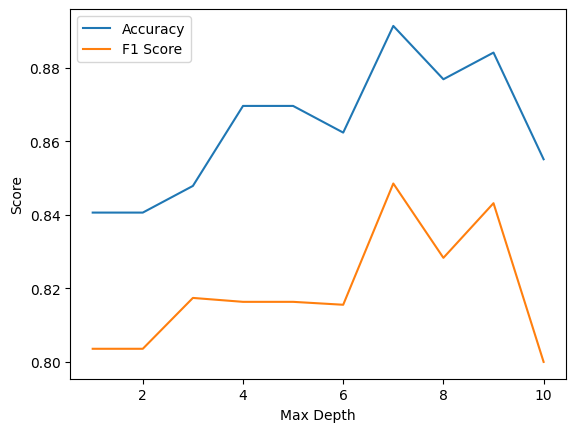

In [22]:
# code
from sklearn.metrics import accuracy_score as sk_accuracy_score, f1_score as sk_f1_score

max_depth = [1,2,3,4,5,6,7,8,9,10]

accuracy_scores_list = []
f1_scores_list = []

for depth in max_depth:
  clf = DecisionTreeClassifier(max_depth=depth, random_state=random_state)
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  accuracy_scores_list.append(sk_accuracy_score(y_test, y_pred))
  f1_scores_list.append(sk_f1_score(y_test, y_pred))

plt.plot(max_depth, accuracy_scores_list, label='Accuracy')
plt.plot(max_depth, f1_scores_list, label='F1 Score')
plt.legend()
plt.xlabel('Max Depth')
plt.ylabel('Score')
plt.show()

### 2.2. Tìm kiếm siêu tham số

In [23]:
from numpy._core.function_base import linspace
#code

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

def grid_search(algorithm, n_jobs, dict_param):
    if(algorithm == 'DecisionTree'):
        model = DecisionTreeClassifier()
    elif(algorithm == 'RandomForest'):
        model = RandomForestClassifier()
    classiffier = GridSearchCV(estimator = model, cv = 5, param_grid = dict_param,
                               n_jobs = n_jobs, scoring='f1')
    classiffier.fit(X_train, y_train)
    print('Best model', end = '')
    print(classiffier.best_estimator_)
    return classiffier.best_estimator_

def evaluate(model):
    # Re-importing inside to ensure we use the functions, not the list variables
    from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
    print("Train Accuracy :", accuracy_score(y_train, model.predict(X_train)))
    print("Train f1 score :", f1_score(y_train, model.predict(X_train)))
    print("Train roc auc :", roc_auc_score(y_train, model.predict(X_train)))
    print("Train Confusion Matrix:")
    print(confusion_matrix(y_train, model.predict(X_train)))
    print("-"*50)
    print("Test Accuracy :", accuracy_score(y_test, model.predict(X_test)))
    print("Test f1 score :", f1_score(y_test, model.predict(X_test)))
    print("Test roc auc :", roc_auc_score(y_test, model.predict(X_test)))
    print("Test Confusion Matrix:")
    print(confusion_matrix(y_test, model.predict(X_test)))

def plot_learning_curve(estimator, title, label_curve, X, y, ylim = None, cv = None,
                         n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5), new_plot=False, idx_color = 0):
    if new_plot:
        plt.title(title)
        plt.xlabel("Training examples")
        plt.ylabel("Score")
        plt.grid()

    if ylim is not None:
        plt.ylim(*ylim)

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="f1")
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color='g')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='r')
    plt.plot(train_sizes, train_scores_mean, 'o-', color='g',
             label=label_curve['train'])
    plt.plot(train_sizes, test_scores_mean, 'o-', color='r',
             label=label_curve['test'])
    plt.legend(loc="best")
    return plt

## 3. Random Forest

### 3.1 Khảo sát các giá trị khác nhau của n_estimators

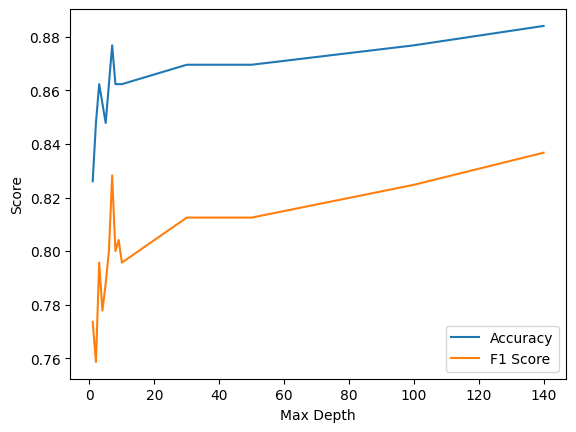

In [24]:
#code

n_estimators = [1,2,3,4,5,6,7,8,9,10,30,50,100,140]

accuracy_scores_list = []
f1_scores_list = []

for n in n_estimators:
  clf = RandomForestClassifier(n_estimators=n, random_state=random_state)
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  accuracy_scores_list.append(sk_accuracy_score(y_test, y_pred))
  f1_scores_list.append(sk_f1_score(y_test, y_pred))

plt.plot(n_estimators, accuracy_scores_list, label='Accuracy')
plt.plot(n_estimators, f1_scores_list, label='F1 Score')
plt.legend()

plt.xlabel('Max Depth')
plt.ylabel('Score')
plt.show()


### 3.2 Tìm kiếm siêu tham số

Tim best-forest
Best modelRandomForestClassifier(max_depth=7, max_features=10, min_samples_leaf=15,
                       n_estimators=8)
Train Accuracy : 0.8840579710144928
Train f1 score : 0.8796992481203008
Train roc auc : 0.8860853040540541
Train Confusion Matrix:
[[254  42]
 [ 22 234]]
--------------------------------------------------
Test Accuracy : 0.855072463768116
Test f1 score : 0.803921568627451
Test roc auc : 0.8444895199459095
Test Confusion Matrix:
[[77 10]
 [10 41]]
Ve Learning Curve


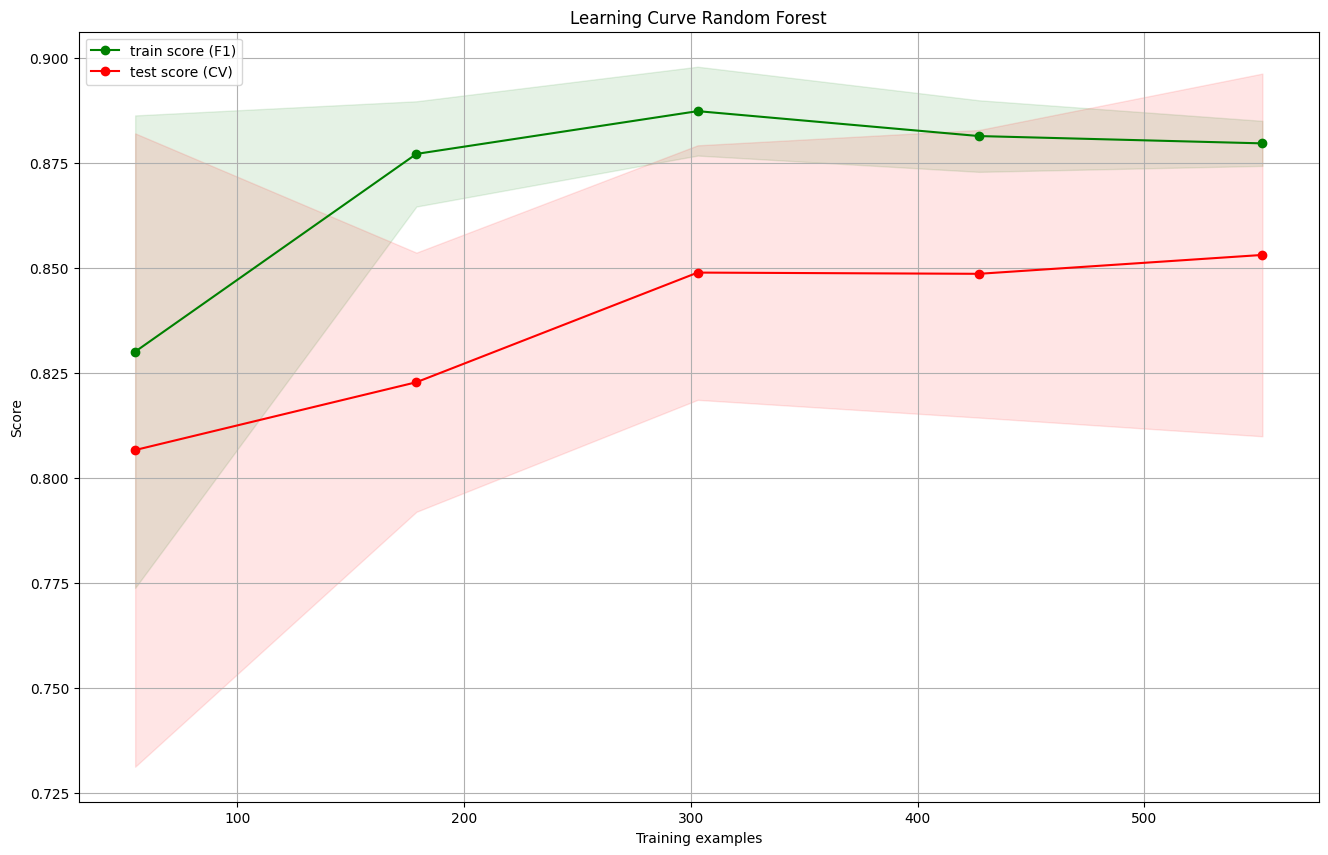

In [27]:
# code

dict_param = {
    'n_estimators': [8, 9, 10, 20, 100],
    'max_depth': [3, 5, 7, 9, 10],
    'min_samples_leaf': [1, 5, 7, 9, 15, 24],
    'max_features':  [4, 6, 10, 16]}

print("Tim best-forest")
best_forest = grid_search('RandomForest', n_jobs=-1, dict_param=dict_param)
evaluate(best_forest)
print("Ve Learning Curve")
plt.figure(figsize=(16,10))
title = 'Learning Curve Random Forest'
label_curve = {'train': 'train score (F1)', 'test': 'test score (CV)'}
plot_learning_curve(best_forest, title, label_curve, X, y, cv=5, new_plot=True)
plt.show()